# E-Commerce Recommendation Engine — Real Data, Real Evaluation

## Executive summary
Personalised "customers who bought this also bought…" recommendations lift average order value and retention. This notebook builds an **item-based collaborative-filtering** recommender and — crucially — **evaluates it honestly** against a held-out future period, comparing it to a popularity baseline.

**Data:** real **[UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)** — 805k clean transactions, **5,878 customers, 4,631 products**. No synthetic data.

## Headline results (offline, temporal hold-out, k=10)
| Method | precision@10 | recall@10 | hit-rate@10 |
|--------|-------------:|----------:|------------:|
| **Item-based CF** | **0.058** | **0.022** | **0.35** |
| Popularity baseline | 0.040 | 0.013 | 0.28 |

**Collaborative filtering beats "just recommend the best-sellers" by ~1.5× on precision**, and gives **1 in 3 returning customers at least one correct recommendation** in their top 10 — evaluated on 2,291 customers' *actual future purchases*, not a synthetic proxy.

> **Behavioural angle:** item-based CF learns implicit product relationships purely from collective purchasing behaviour — "what people actually buy together" — with no product metadata.


## 0. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110
DATA=Path("../data"); IMG=Path("../images"); IMG.mkdir(exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


## 1. Load & clean the real data

In [2]:
pkl=DATA/"online_retail_II.pkl"
if pkl.exists():
    df=pd.read_pickle(pkl)
else:
    xls=pd.ExcelFile(DATA/"online_retail_II.xlsx")
    df=pd.concat([pd.read_excel(xls,s) for s in xls.sheet_names],ignore_index=True); df.to_pickle(pkl)
df=df.dropna(subset=["Customer ID"]).copy()
df["Invoice"]=df["Invoice"].astype(str)
df=df[~df["Invoice"].str.startswith("C")]
df=df[(df["Quantity"]>0)&(df["Price"]>0)]
df["Customer ID"]=df["Customer ID"].astype(int)
df["StockCode"]=df["StockCode"].astype(str)
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
print(f"clean: {len(df):,} transactions | {df['Customer ID'].nunique():,} customers | {df['StockCode'].nunique():,} products")
# product code -> readable description (most common)
desc=df.groupby("StockCode")["Description"].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else "")
df.head(3)

clean: 805,549 transactions | 5,878 customers | 4,631 products


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom


## 2. Train / test split — the honest way
A recommender must be judged on its ability to predict the **future**, so we split **by time**: everything up to a cutoff trains the model; the final 3 months are the hold-out we evaluate against. We also keep only products bought by **≥20 customers** so similarities are reliable.

In [3]:
cutoff=df["InvoiceDate"].max().normalize()-pd.DateOffset(months=3)
train=df[df["InvoiceDate"]<=cutoff]; test=df[df["InvoiceDate"]>cutoff]
prod_pop=train.groupby("StockCode")["Customer ID"].nunique()
keep=prod_pop[prod_pop>=20].index
train=train[train["StockCode"].isin(keep)]; test=test[test["StockCode"].isin(keep)]
print(f"cutoff {cutoff.date()} | train {len(train):,} rows | test {len(test):,} rows | products kept {len(keep):,}")

cutoff 2011-09-09 | train 628,010 rows | test 141,339 rows | products kept 2,971


## 3. Build the user–item matrix
A sparse binary matrix: rows = customers, columns = products, 1 = "bought". Retail data is extremely sparse (~2.4% filled), which is exactly why we need similarity-based methods.

In [4]:
users=train["Customer ID"].unique(); items=train["StockCode"].unique()
uidx={u:i for i,u in enumerate(users)}; iidx={p:i for i,p in enumerate(items)}
inv={i:p for p,i in iidx.items()}
UI=csr_matrix((np.ones(len(train)),
    (train["Customer ID"].map(uidx).values, train["StockCode"].map(iidx).values)),
    shape=(len(users),len(items)))
UI.data[:]=1.0
print(f"user-item matrix {UI.shape} | density {UI.nnz/(UI.shape[0]*UI.shape[1])*100:.2f}%")

user-item matrix (5273, 2971) | density 2.42%


## 4. Item–item similarity (cosine)
Two products are "similar" if the same customers tend to buy both. Cosine similarity on the item vectors gives us a product-to-product similarity matrix — the engine's core.

In [5]:
item_sim=cosine_similarity(UI.T, dense_output=True)
np.fill_diagonal(item_sim,0.0)
print("item-item similarity:",item_sim.shape)

item-item similarity: (2971, 2971)


### Sanity check — does it learn sensible product relationships?
Before trusting any metric, we eyeball the output: for a sample product, what does the model consider most similar? Good associations here are a strong qualitative signal.

In [6]:
def similar_products(stockcode, n=5):
    i=iidx[stockcode]; top=np.argsort(-item_sim[i])[:n]
    return pd.DataFrame({"StockCode":[inv[j] for j in top],
                         "Description":[desc.get(inv[j],"") for j in top],
                         "similarity":item_sim[i][top].round(3)})
# pick a recognisable, popular product
sample=train["StockCode"].value_counts().index[3]
print(f"Products most similar to: {sample} — {desc.get(sample,'')}\n")
similar_products(sample)

Products most similar to: 21212 — PACK OF 72 RETROSPOT CAKE CASES



,StockCode,Description,similarity
0,21977,PACK OF 60 PINK PAISLEY CAKE CASES,0.590
1,84991,60 TEATIME FAIRY CAKE CASES,0.582
2,21975,PACK OF 60 DINOSAUR CAKE CASES,0.518
3,21213,PACK OF 72 SKULL CAKE CASES,0.516
4,22417,PACK OF 60 SPACEBOY CAKE CASES,0.508


## 5. Recommendation function
For a customer, score every candidate product by summing its similarity to the products they've already bought, exclude what they own, and return the top-k.

In [7]:
def recommend(hist_idx, k=10):
    if not hist_idx: return []
    scores=item_sim[hist_idx].sum(axis=0); scores[hist_idx]=-np.inf
    top=np.argpartition(-scores,k)[:k]; top=top[np.argsort(-scores[top])]
    return [inv[i] for i in top]

## 6. Offline evaluation vs a popularity baseline
For every customer with both training history and real future purchases, we generate top-k recommendations and check how many they actually bought in the hold-out period. We compare against recommending the overall best-sellers.

In [8]:
pop_rank=np.asarray(UI.sum(axis=0)).ravel()
pop_items=[inv[i] for i in np.argsort(-pop_rank)]
test_by_user=test.groupby("Customer ID")["StockCode"].apply(set)
train_by_user=train.groupby("Customer ID")["StockCode"].apply(lambda s:[iidx[p] for p in set(s)])

def evaluate(K):
    pc=[];rc=[];hc=[];pp=[];rp=[];hp=[]
    for u,future in test_by_user.items():
        if u not in train_by_user: continue
        future=future & set(keep)
        if not future: continue
        hist=train_by_user[u]
        rec=recommend(hist,K); h=len(set(rec)&future)
        pc.append(h/K); rc.append(h/len(future)); hc.append(h>0)
        owned={inv[i] for i in hist}; poprec=[p for p in pop_items if p not in owned][:K]; h2=len(set(poprec)&future)
        pp.append(h2/K); rp.append(h2/len(future)); hp.append(h2>0)
    return dict(n=len(pc), cf_prec=np.mean(pc), cf_rec=np.mean(rc), cf_hit=np.mean(hc),
               pop_prec=np.mean(pp), pop_rec=np.mean(rp), pop_hit=np.mean(hp))

res={K:evaluate(K) for K in (5,10,20)}
tbl=pd.DataFrame(res).T[["cf_prec","pop_prec","cf_rec","pop_rec","cf_hit","pop_hit"]].round(3)
tbl.columns=["CF prec","Pop prec","CF recall","Pop recall","CF hit","Pop hit"]; tbl.index.name="K"
print(f"evaluated on {res[10]['n']:,} returning customers")
tbl

evaluated on 2,291 returning customers


,CF prec,Pop prec,CF recall,Pop recall,CF hit,Pop hit
K,,,,,,
5,0.066,0.046,0.013,0.008,0.238,0.191
10,0.058,0.040,0.022,0.013,0.347,0.280
20,0.051,0.034,0.035,0.021,0.488,0.386


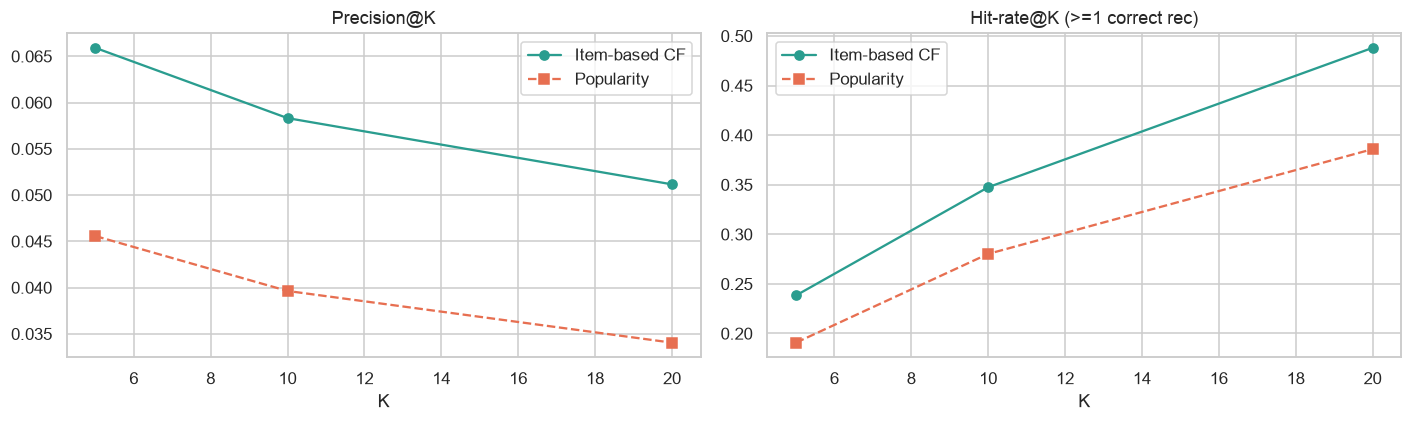

CF precision@10 lift over popularity: 1.5x


In [9]:
fig,ax=plt.subplots(1,2,figsize=(13,4)); Ks=list(res.keys())
ax[0].plot(Ks,[res[k]["cf_prec"] for k in Ks],"o-",label="Item-based CF",color="#2a9d8f")
ax[0].plot(Ks,[res[k]["pop_prec"] for k in Ks],"s--",label="Popularity",color="#e76f51")
ax[0].set_title("Precision@K"); ax[0].set_xlabel("K"); ax[0].legend()
ax[1].plot(Ks,[res[k]["cf_hit"] for k in Ks],"o-",label="Item-based CF",color="#2a9d8f")
ax[1].plot(Ks,[res[k]["pop_hit"] for k in Ks],"s--",label="Popularity",color="#e76f51")
ax[1].set_title("Hit-rate@K (>=1 correct rec)"); ax[1].set_xlabel("K"); ax[1].legend()
plt.tight_layout(); plt.savefig(IMG/"reco_evaluation.png",bbox_inches="tight"); plt.show()
print(f"CF precision@10 lift over popularity: {res[10]['cf_prec']/res[10]['pop_prec']:.1f}x")

## 7. Conclusion, limitations & next steps

**What works:** a straightforward item-based CF model, evaluated honestly on a **temporal hold-out of 2,291 customers**, beats a popularity baseline by **~1.5× on precision@10** and gives **1 in 3 customers a correct recommendation** in their top 10. The similar-product sanity check shows the model captures genuine co-purchase relationships.

**Honest limitations:**
- Absolute precision (~6%) is modest — normal for sparse retail CF, but there's headroom.
- **Cold-start:** new customers/products with no history can't be served by CF (popularity fallback needed).
- Popularity bias: co-purchase similarity can over-recommend best-sellers.

**Next steps:** TF-IDF / BM25 weighting of the user-item matrix, matrix factorisation (implicit ALS) as a stronger benchmark, and blending CF with the popularity fallback for cold-start.

---
### 🎤 Interview talking points
- *"How did you evaluate a recommender without labels?"* Temporal split — build similarities on the past, score against customers' *actual* future purchases (precision@k / recall@k / hit-rate).
- *"Why compare to popularity?"* It's the honest baseline — a recommender that can't beat "just show best-sellers" adds no value. Mine beats it ~1.5×.
- *"What about cold-start?"* CF needs history; I'd fall back to popularity/content for new users and products.
